In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns


Loading and preprocess dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path_1 = "/content/drive/MyDrive/2024_2025/PSM_2024_2025/Regression_3/train_titanic.csv"
file_path_2 = "/content/drive/MyDrive/2024_2025/PSM_2024_2025/Regression_3/test_titanic.csv"

In [ ]:
train_titanic = pd.read_csv(file_path_1)
test_titanic = pd.read_csv(file_path_2)

In [ ]:
print(train_titanic.head(n = 10))

print(train_titanic.info())

   Unnamed: 0  PassengerId  Survived  Sex     Age      Fare  Pclass_1  \
0           0            1         0    1  0.2750  0.014151         0   
1           1            2         1    0  0.4750  0.139136         1   
2           2            3         1    0  0.3250  0.015469         0   
3           3            4         1    0  0.4375  0.103644         1   
4           4            5         0    1  0.4375  0.015713         0   
5           5            6         0    1  0.3500  0.016510         0   
6           6            7         0    1  0.6750  0.101229         1   
7           7            8         0    1  0.0250  0.041136         0   
8           8            9         1    0  0.3375  0.021731         0   
9           9           10         1    0  0.1750  0.058694         0   

   Pclass_2  Pclass_3  Family_size  Title_1  Title_2  Title_3  Title_4  Emb_1  \
0         0         1          0.1        1        0        0        0      0   
1         0         0          0.1

In [ ]:
print(test_titanic.info())

In [ ]:
# dropping unnecessary columns(first 2)
train_titanic.drop(['Unnamed: 0', 'PassengerId'], axis=1,inplace = True)
test_titanic.drop(['Unnamed: 0', 'PassengerId'], axis=1,inplace = True)

In [ ]:
# allocating Survived column in Y_train and other columns in X_train
X_train = train_titanic.iloc[:,1:]
Y_train = train_titanic.iloc[:,:1]
X_test = test_titanic.iloc[:,1:]
Y_test = test_titanic.iloc[:,:1]

In [ ]:
# chceking is there any missing values
for column in X_train.columns:
    print(X_train[column].isna().value_counts())


Sex
False    792
Name: count, dtype: int64
Age
False    792
Name: count, dtype: int64
Fare
False    792
Name: count, dtype: int64
Pclass_1
False    792
Name: count, dtype: int64
Pclass_2
False    792
Name: count, dtype: int64
Pclass_3
False    792
Name: count, dtype: int64
Family_size
False    792
Name: count, dtype: int64
Title_1
False    792
Name: count, dtype: int64
Title_2
False    792
Name: count, dtype: int64
Title_3
False    792
Name: count, dtype: int64
Title_4
False    792
Name: count, dtype: int64
Emb_1
False    792
Name: count, dtype: int64
Emb_2
False    792
Name: count, dtype: int64
Emb_3
False    792
Name: count, dtype: int64


Create and train the logistic regression model

In [ ]:
help(LogisticRegression)

In [ ]:
model = LogisticRegression(max_iter=1000, solver='liblinear')  # Using liblinear solver
model.fit(X_train, Y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=1000, solver='liblinear')

In [ ]:
# Predictions and evaluations
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [ ]:
y_pred

array([0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0])

In [ ]:
y_pred_proba

array([0.24706937, 0.19581944, 0.49611525, 0.08638965, 0.19885779,
       0.94019703, 0.60017772, 0.12119783, 0.51055754, 0.20821576,
       0.76029521, 0.84652628, 0.65088066, 0.08450989, 0.08106652,
       0.35196375, 0.64489056, 0.19885779, 0.89582274, 0.08548196,
       0.07563202, 0.20589165, 0.39765909, 0.08151914, 0.38144895,
       0.63159761, 0.22585789, 0.07123384, 0.3347848 , 0.85552258,
       0.08464624, 0.35460191, 0.56476456, 0.35848478, 0.09935479,
       0.08766694, 0.82800203, 0.09942952, 0.85800292, 0.6978289 ,
       0.75373191, 0.12367912, 0.08822637, 0.09302165, 0.91644712,
       0.09017101, 0.08370681, 0.08404246, 0.49585547, 0.0910591 ,
       0.24407271, 0.94459953, 0.115687  , 0.09403266, 0.07207831,
       0.01355811, 0.11525276, 0.1913302 , 0.93600322, 0.3079656 ,
       0.05095759, 0.67973343, 0.914896  , 0.76848146, 0.5893267 ,
       0.87367961, 0.32711234, 0.58574808, 0.12367912, 0.05076449,
       0.20052792, 0.89528685, 0.19581944, 0.2278933 , 0.80299

ROC Curve and AUC

In [ ]:
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

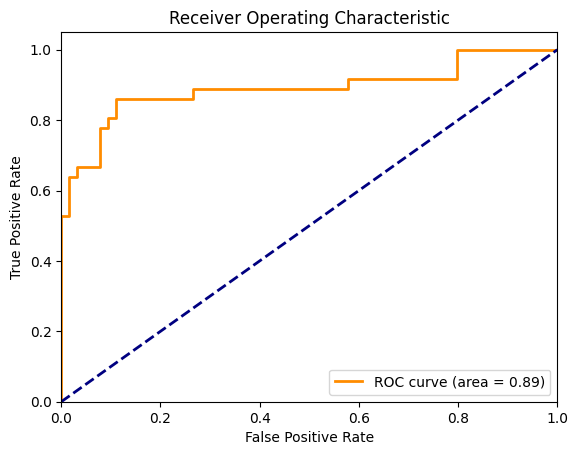

In [ ]:
# Plotting ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

Print classification report and confusion matrix

In [ ]:
print("Classification Report:\n", classification_report(Y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.91      0.90        64
           1       0.83      0.81      0.82        36

    accuracy                           0.87       100
   macro avg       0.86      0.86      0.86       100
weighted avg       0.87      0.87      0.87       100

Confusion Matrix:
 [[58  6]
 [ 7 29]]


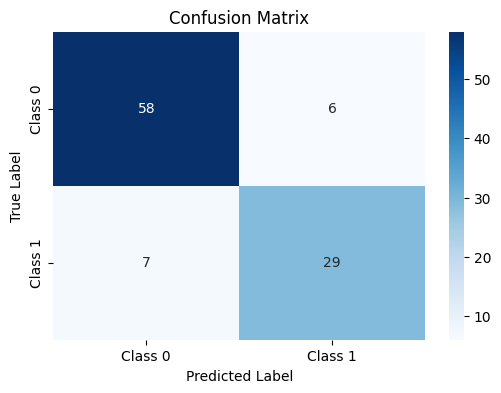

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(Y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

###############################################################################################

Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Initialize and train the Decision Tree model
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Make predictions
y_pred = model_dt.predict(X_test)
y_pred_proba = model_dt.predict_proba(X_test)[:, 1]

In [ ]:
y_pred

In [ ]:
y_pred_proba

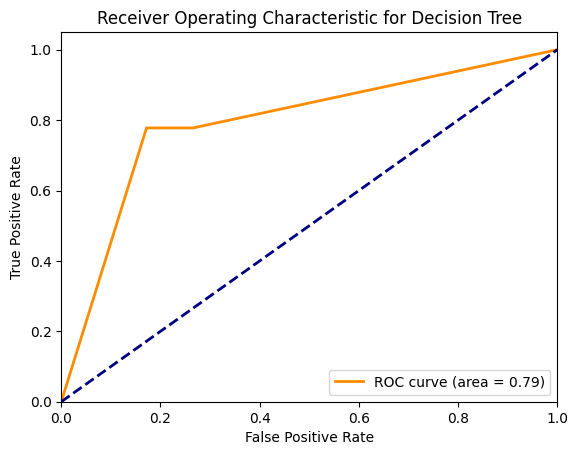

In [ ]:
# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Decision Tree')
plt.legend(loc="lower right")
plt.show()

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.81      0.84        64
           1       0.70      0.78      0.74        36

    accuracy                           0.80       100
   macro avg       0.78      0.80      0.79       100
weighted avg       0.81      0.80      0.80       100



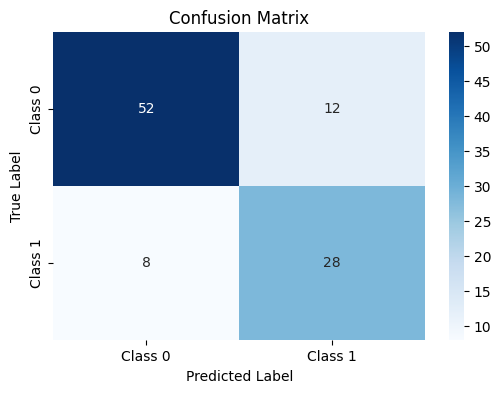

In [ ]:
# Print classification report
print("Classification Report:\n", classification_report(Y_test, y_pred))

# Compute and visualize the confusion matrix
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

#################################################################################################

Random Forest classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Initialize and train the Decision Tree model
model_rf = RandomForestClassifier(n_estimators = 100, random_state=42)
model_rf.fit(X_train, Y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(random_state=42)

In [ ]:
# Make predictions
y_pred = model_rf.predict(X_test)
y_pred_proba = model_rf.predict_proba(X_test)[:, 1]

In [ ]:
y_pred

In [ ]:
y_pred_proba

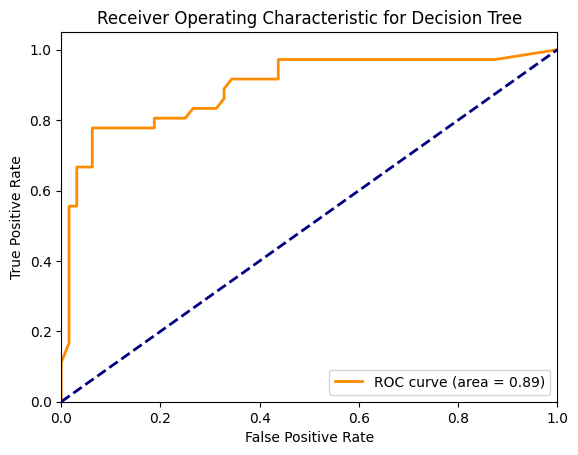

In [ ]:
# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Decision Tree')
plt.legend(loc="lower right")
plt.show()

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.89      0.88        64
           1       0.80      0.78      0.79        36

    accuracy                           0.85       100
   macro avg       0.84      0.83      0.84       100
weighted avg       0.85      0.85      0.85       100



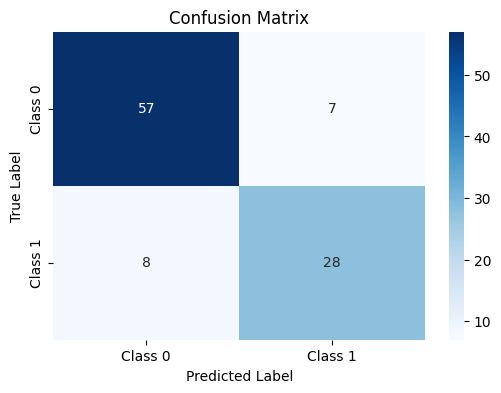

In [ ]:
# Print classification report
print("Classification Report:\n", classification_report(Y_test, y_pred))

# Compute and visualize the confusion matrix
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

###################################################################################################

Decision tree and Random Forest regressors

In [ ]:
file_path = "/content/drive/MyDrive/2024_2025/PSM_2024_2025/Regression_3/winequality-white.csv"

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv(file_path, delimiter=";")  # Use ';' as delimiter for wine dataset

# Separate features (X) and target variable (Y)
X = df.drop(columns=["quality"])  # Features
Y = df["quality"]  # Target variable

In [ ]:
# Normalize features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.3, random_state=42)

In [ ]:
# Initialize and train Decision Tree Regressor
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train, Y_train)

# Predictions using Decision Tree
y_pred_dt = dt_regressor.predict(X_test)

# Compute evaluation metrics for Decision Tree
mse_dt = mean_squared_error(Y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(Y_test, y_pred_dt)

In [ ]:
# Initialize and train Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, Y_train)

# Predictions using Random Forest
y_pred_rf = rf_regressor.predict(X_test)

# Compute evaluation metrics for Random Forest
mse_rf = mean_squared_error(Y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(Y_test, y_pred_rf)

In [ ]:
# Print results
print("Decision Tree Regressor Metrics:")
print(f"MSE: {mse_dt:.3f}, RMSE: {rmse_dt:.3f}, R2 Score: {r2_dt:.3f}\n")

print("Random Forest Regressor Metrics:")
print(f"MSE: {mse_rf:.3f}, RMSE: {rmse_rf:.3f}, R2 Score: {r2_rf:.3f}")

Decision Tree Regressor Metrics:
MSE: 0.709, RMSE: 0.842, R2 Score: 0.061

Random Forest Regressor Metrics:
MSE: 0.358, RMSE: 0.598, R2 Score: 0.526
